# Experiment 2: Temporal Irreducibility

Trains a spiking neural network (SNN) on standard TEMPO v1.1 data and evaluates
it under three test conditions that progressively remove temporal structure:

| Condition | What is preserved | What is destroyed |
|-----------|-------------------|-------------------|
| **Intact** | All spike timing | — |
| **Shuffled** | Spike counts per channel; channel assignment | Inter-spike intervals; temporal ordering |
| **Time-collapsed** | Only spike counts per channel | All timing information |

**Expected outcome**
- *Intact*: high accuracy.
- *Shuffled*: substantial accuracy drop; may stay above chance for letters with
  unique (dot-count, dash-count) signatures.
- *Time-collapsed*: accuracy is bounded above by the count-only ceiling (50%, 13/26) —
  the theoretical maximum for any classifier using only spike counts. The unique-count
  baseline (26.9%, 7/26) marks letters whose (dot, dash) signature is shared by no
  other letter (e.g. E, T, M, O); letters like D/R/U share the same 2-dot 1-dash
  signature and are indistinguishable without timing.

---

## Run History

| Run | Architecture | Seeds | Intact | Shuffled | Collapsed | Δ(I−S) |
|-----|-------------|:-----:|:------:|:--------:|:---------:|:-------:|
| Run 1 | Baseline (β=0.95, thr=1.0, lr=5e-3) | 3 | 3.85% ± 0.00 | 3.82% ± 0.05 | 2.74% ± 2.12 | ~0 pp |
| Run 2 | β=0.98 learn_beta, thr=0.3, lr=1e-3, grad clip | 3 | 11.28% ± 7.17 | 10.95% ± 6.48 | 4.05% ± 0.19 | ~0 pp |
| Run 3 | Multi-Timescale LIF SNN: soft reset, Uniform[−2,2] init, cosine LR | 3 | 62.44% ± 3.07 | 27.97% ± 0.89 | 3.03% ± 1.43 | +34.5 pp |
| Run 4 | Run 3 + N_TRAIN=500, N_TEST=100, N_EPOCHS=100, learn_beta=True on lif2 | 3 | 74.53% ± 0.16 | 26.13% ± 1.29 | 3.85% ± 0.00 | +48.4 pp |
| Run 5 | Run 4 configuration, 3× L40S GPU, M2 revision | 10 | 73.38% ± 0.80 | 25.77% ± 1.57 | 3.85% ± 0.00 | +47.6 pp |
| Run 6 | Run 5 + Exp52 params: σ~HN(0.310Tu), T_thresh=1.96, r=[2.5,6.0], ω=[0.8,1.5] | 10 | — (halted) | — | — | — |
| Run 7 | Run 6 + pre-loaded GPU data per seed; sequential training; set_to_none=False; CUDA graphs disabled (OOM on 4GB GPU) | 10 | 73.38% ± 0.80 | 25.77% ± 1.57 | 3.85% ± 0.00 | +47.6 pp |
| **Run 8** | **Run 7 + CUDA graphs enabled (L40S 44 GB budget); parallel training across 3 GPUs (1 seed per GPU per round)** | **10** | **75.65% ± 1.10** | **27.49% ± 1.29** | **3.85% ± 0.00** | **+48.2 pp** |

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
from torch.utils.data import DataLoader, TensorDataset
import concurrent.futures
import threading
import math

try:
    import snntorch as snn
    from snntorch import surrogate
    print(f"snnTorch {snn.__version__}")
except ImportError:
    print("snnTorch not found.  Install with:  pip install snntorch")
    raise

# Import TEMPO encoder (project root must be on sys.path)
try:
    from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE
except ImportError:
    sys.path.insert(0, os.path.abspath('..'))
    from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device selection ───────────────────────────────────────────────────────
# NOTE: For this model (3.7k params, [64,2]→[64,128]→[64,26] per time step),
# MPS/CUDA kernel-launch overhead dominates computation for the small matrices.
# The sequential time loop dispatches 1600 tiny ops per batch, causing MPS to
# be SLOWER than CPU.  The forward pass fix below (fc1 batching) reduces MPS
# dispatches from 1600 to 1, after which MPS/CUDA does help.
# Set FORCE_CPU=True if you observe only one core active and slow throughput.
FORCE_CPU = False

if FORCE_CPU:
    device = torch.device("cpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device : {device}")
print(f"NumPy  {np.__version__},  PyTorch {torch.__version__},  seed={SEED}")

# ── Multi-GPU configuration ───────────────────────────────────────────────
N_CUDA_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
if N_CUDA_GPUS > 0:
    GPU_DEVICES = [torch.device(f'cuda:{i}') for i in range(N_CUDA_GPUS)]
    # USE_AMP requires BF16 (Ampere CC>=8.0); FP16 needs GradScaler which is
    # incompatible with CUDA graph capture. On older GPUs, run without AMP.
    _bf16 = torch.cuda.get_device_properties(0).major >= 8
    USE_AMP = _bf16
    print(f'CUDA GPUs detected: {N_CUDA_GPUS}')
    for i in range(N_CUDA_GPUS):
        props = torch.cuda.get_device_properties(i)
        bf16 = props.major >= 8
        print(f'  cuda:{i}  {props.name}  {props.total_memory/1024**3:.0f} GB  BF16={bf16}  USE_AMP={bf16}')
else:
    GPU_DEVICES = [device]
    USE_AMP = False
    print(f'No CUDA GPUs — using {device}')
N_GPU_WORKERS = len(GPU_DEVICES)
print(f'GPU workers : {N_GPU_WORKERS}')

snnTorch 0.9.4
Device : cuda
NumPy  1.26.3,  PyTorch 2.7.1+cu128,  seed=42
CUDA GPUs detected: 3
  cuda:0  NVIDIA L40S  44 GB  BF16=True  USE_AMP=True
  cuda:1  NVIDIA L40S  44 GB  BF16=True  USE_AMP=True
  cuda:2  NVIDIA L40S  44 GB  BF16=True  USE_AMP=True
GPU workers : 3


/home/LukeHindman/.local/lib/python3.9/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
# ── Transmission ──────────────────────────────────────────────────────────
WPM   = 20
T_U   = 1200.0 / WPM        # 60 ms at 20 WPM

# ── TEMPO parameters — Run 6 (Experiment 52 + Experiment 1 Run 2 recalibration)
# Protocol sigma (fixed, jointly calibrated with T_thresh in Experiment 1)
SIGMA           = 0.575      # sigma = 0.575 T_u
T_THRESH        = 1.92       # channel decision boundary (× T_u); jointly calibrated in Exp 1
# LogNormal parameters (MLE fit, Experiment 52, n=36 recordings)
MU_R,     SIGMA_R     = 1.2269, 0.2916   # log-space mean and std of r
MU_OMEGA, SIGMA_OMEGA = 0.0360, 0.2446   # log-space mean and std of omega
MAX_T = 1600                 # fixed time axis length (ms bins); covers 99.9% of samples

# ── Dataset ───────────────────────────────────────────────────────────────
LETTERS   = sorted(k for k in MORSE_TABLE if k.isalpha())
N_CLASSES = len(LETTERS)     # 26
N_TRAIN  = 500
N_TEST   = 100

# ── Training ──────────────────────────────────────────────────────────────
N_EPOCHS   = 100
BATCH_SIZE = 256

# ── Experiment ────────────────────────────────────────────────────────────
N_SEEDS = 10

print(f'T_u        = {T_U:.0f} ms')
print(f'sigma      = {SIGMA} T_u = {SIGMA*T_U:.2f} ms  (fixed, jointly calibrated)')
print(f'T_thresh   = {T_THRESH} T_u = {T_THRESH*T_U:.2f} ms')
print(f'r          ~ LogNormal(mu={MU_R}, sigma={SIGMA_R})  median={2.718**MU_R:.3f}')
print(f'omega      ~ LogNormal(mu={MU_OMEGA}, sigma={SIGMA_OMEGA})  median={2.718**MU_OMEGA:.3f}')
print(f'Letters    : {" ".join(LETTERS)}')
print(f'Max T      : {MAX_T} ms bins')
print(f'Train      : {N_CLASSES} x {N_TRAIN} = {N_CLASSES*N_TRAIN} samples')
print(f'Test       : {N_CLASSES} x {N_TEST}  = {N_CLASSES*N_TEST} samples')
print(f'Epochs     : {N_EPOCHS}  (cosine LR: 5e-4 to 1e-5)')
print(f'Batch size : {BATCH_SIZE}')
print(f'Seeds      : {N_SEEDS}')


T_u        = 60 ms
sigma      = 0.575 T_u = 34.50 ms  (fixed, jointly calibrated)
T_thresh   = 1.92 T_u = 115.20 ms
r          ~ LogNormal(mu=1.2269, sigma=0.2916)  median=3.410
omega      ~ LogNormal(mu=0.036, sigma=0.2446)  median=1.037
Letters    : A B C D E F G H I J K L M N O P Q R S T U V W X Y Z
Max T      : 1600 ms bins
Train      : 26 x 500 = 13000 samples
Test       : 26 x 100  = 2600 samples
Epochs     : 100  (cosine LR: 5e-4 to 1e-5)
Batch size : 256
Seeds      : 10


In [3]:
# ── TEMPO Encoder ──────────────────────────────────────────────────────────
# Inline encoder using current paper parameters (LogNormal r and omega,
# fixed sigma, jointly calibrated T_thresh from Experiment 1).

def encode_letter_r6(letter, t_u, rng, use_noise=True):
    """
    Encode a single Morse letter into a dual-channel spike train using
    current paper parameters (σ fixed, r and ω LogNormal).

    Sigma is the fixed protocol value SIGMA * t_u.
    r and omega are sampled from LogNormal distributions fitted in Experiment 52.
    Channel assignment uses T_THRESH = 1.92 * t_u (jointly calibrated in Exp 1).

    Returns list of (timestamp_ms, channel) tuples; channel 0=dot, 1=dash.
    """
    # Protocol parameters
    sigma = SIGMA * t_u if use_noise else 0.0
    omega = rng.lognormal(MU_OMEGA, SIGMA_OMEGA)  if use_noise else 1.0
    r     = rng.lognormal(MU_R,     SIGMA_R)      if use_noise else 3.0
    t_thresh = T_THRESH * t_u
    min_dur  = 0.1 * t_u

    t_cur  = 0.0
    spikes = []
    pattern = MORSE_TABLE[letter]

    for element in pattern:
        t_ideal  = (1.0 if element == '.' else r) * t_u
        t_noisy  = t_ideal * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
        t_final  = max(t_noisy, min_dur)
        t_spike  = t_cur + t_final
        channel  = 0 if t_final < t_thresh else 1
        spikes.append((t_spike, channel))
        # Intra-character gap after each element
        gap = max(1.0 * t_u * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0), min_dur)
        t_cur = t_spike + gap

    # Replace last intra-char gap with inter-character gap (TEMPO spec)
    if spikes:
        gap = max(3.0 * t_u * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0), min_dur)
        t_cur = spikes[-1][0] + gap

    # Inter-word gap at end (single-letter training: letter is its own word)
    if spikes:
        gap = max(7.0 * t_u * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0), min_dur)
        t_cur = spikes[-1][0] + gap  # noqa: F841

    return spikes


# Smoke-test: encode a few letters, check channels are reasonable
_rng_test = np.random.default_rng(0)
for _ltr in ['E', 'T', 'A', 'H']:
    _sp = encode_letter_r6(_ltr, T_U, _rng_test, use_noise=False)
    _chs = [c for _, c in _sp]
    print(f'  {_ltr} ({MORSE_TABLE[_ltr]}): {len(_sp)} spikes  channels={_chs}')
print('encode_letter_r6 OK')


  E (.): 1 spikes  channels=[0]
  T (-): 1 spikes  channels=[1]
  A (.-): 2 spikes  channels=[0, 1]
  H (....): 4 spikes  channels=[0, 0, 0, 0]
encode_letter_r6 OK


## Letter Count Analysis

Before running any SNN, we can bound the time-collapsed condition by analysing
(dot-count, dash-count) signatures.  Two reference values are derived:

- **Unique-count baseline** (lower bound): fraction of letters whose count
  signature is shared by no other letter — a count-based classifier is
  *guaranteed* to identify these correctly.
- **Count-only ceiling** (upper bound): unique letters plus one correct
  identification per ambiguous group — the maximum any count-based
  classifier could achieve assuming perfect within-group disambiguation.

In [4]:
# Map each letter to its (dot_count, dash_count)
letter_counts = {}
for letter in LETTERS:
    pattern = MORSE_TABLE[letter]
    dots   = pattern.count('.')
    dashes = pattern.count('-')
    letter_counts[letter] = (dots, dashes)

# Group letters by count signature
count_groups = defaultdict(list)
for letter, sig in sorted(letter_counts.items()):
    count_groups[sig].append(letter)

print(f"{'Signature':>15}  {'Size':>4}  Letters")
print("-" * 50)
unique_sig, ambig_sig = [], []
for sig in sorted(count_groups):
    group = count_groups[sig]
    size  = len(group)
    mark  = "← unique" if size == 1 else f"← {size}-way ambiguous"
    print(f"({sig[0]}d, {sig[1]}–)  {size:>4}  {', '.join(group)}  {mark}")
    if size == 1:
        unique_sig.append(sig)
    else:
        ambig_sig.append(sig)

unique_letters = [l for sig in unique_sig for l in count_groups[sig]]
ambig_letters  = [l for sig in ambig_sig  for l in count_groups[sig]]

# Two count-based reference values:
#   unique-count baseline  (lower bound) — letters whose (dot,dash) signature
#     is shared by no other letter; a count classifier guarantees these correct.
#   count-only ceiling     (upper bound) — unique letters + one correct per
#     ambiguous group; theoretical maximum for any count-based method.
n_unique      = len(unique_letters)
ceiling       = n_unique / N_CLASSES * 100              # 7/26  ≈ 26.9 %  unique-count baseline
count_ceiling = (n_unique + len(ambig_sig)) / N_CLASSES * 100  # 13/26 = 50.0 %  count-only ceiling
chance        = 100.0 / N_CLASSES

print()
print(f"Letters with unique count signatures ({n_unique}): {' '.join(unique_letters)}")
print(f"Letters in ambiguous groups ({len(ambig_letters)}):  {' '.join(ambig_letters)}")
print()
print(f"Chance level (random)           : {chance:.2f}%")
print(f"Unique-count baseline           : {ceiling:.1f}%  ({n_unique}/{N_CLASSES})")
print(f"Count-only ceiling              : {count_ceiling:.1f}%  ({n_unique + len(ambig_sig)}/{N_CLASSES})")

      Signature  Size  Letters
--------------------------------------------------
(0d, 1–)     1  T  ← unique
(0d, 2–)     1  M  ← unique
(0d, 3–)     1  O  ← unique
(1d, 0–)     1  E  ← unique
(1d, 1–)     2  A, N  ← 2-way ambiguous
(1d, 2–)     3  G, K, W  ← 3-way ambiguous
(1d, 3–)     3  J, Q, Y  ← 3-way ambiguous
(2d, 0–)     1  I  ← unique
(2d, 1–)     3  D, R, U  ← 3-way ambiguous
(2d, 2–)     4  C, P, X, Z  ← 4-way ambiguous
(3d, 0–)     1  S  ← unique
(3d, 1–)     4  B, F, L, V  ← 4-way ambiguous
(4d, 0–)     1  H  ← unique

Letters with unique count signatures (7): T M O E I S H
Letters in ambiguous groups (19):  A N G K W J Q Y D R U C P X Z B F L V

Chance level (random)           : 3.85%
Unique-count baseline           : 26.9%  (7/26)
Count-only ceiling              : 50.0%  (13/26)


## Data Generation

Generates spike trains in-memory using the TEMPO v1.1 encoder.
Train set uses full stochastic corruption; test set is also stochastic
(same corruption level as protocol) to assess generalisation.

In [5]:
def make_spike_tensor(spikes, max_t):
    """Convert [(timestamp_ms, channel)] -> binary tensor [max_t, 2]."""
    tensor = np.zeros((max_t, 2), dtype=np.float32)
    for t, ch in spikes:
        idx = int(round(t))
        if 0 <= idx < max_t:
            tensor[idx, ch] = 1.0
    return tensor


def generate_split(letters, n_per_class, t_u, max_t, stochastic, rng, label=''):
    """Generate a train or test split as dense binary tensors.
    Uses encode_letter_r6 (Run 6 parameters).
    stochastic=True adds sigma/omega/r noise; False gives clean encoding.
    """
    n_total = len(letters) * n_per_class
    X_list, y_list = [], []
    for label_idx, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_letter_r6(letter, t_u, rng, use_noise=stochastic)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(label_idx)
        done = (label_idx + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)  # [N, T, 2]
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


# Generate train and test sets for the first seed (reused across seeds below)
_rng = np.random.default_rng(SEED)
print('Generating data...')
X_train_base, y_train = generate_split(LETTERS, N_TRAIN, T_U, MAX_T, True, _rng, 'Train')
X_test_base,  y_test  = generate_split(LETTERS, N_TEST,  T_U, MAX_T, True, _rng, 'Test')

print(f'X_train : {tuple(X_train_base.shape)}  (N, T, 2)')
print(f'X_test  : {tuple(X_test_base.shape)}')
print(f'Non-zero spikes per sample  train={X_train_base.sum((1,2)).mean():.1f},  '
      f'test={X_test_base.sum((1,2)).mean():.1f}')


Generating data...
  Train: 500/13000

  Train: 1000/13000

  Train: 1500/13000

  Train: 2000/13000

  Train: 2500/13000

...

  Test: 2400/2600

  Test: 2500/2600

  Test: 2600/2600


X_train : (13000, 1600, 2)  (N, T, 2)
X_test  : (2600, 1600, 2)


Non-zero spikes per sample  train=3.1,  test=3.1


## Spike Transforms

Three test-time transformations are applied to the spike tensors `[T, 2]`:

- **Intact** — identity; no change.
- **Shuffled** — permute the time axis of each channel independently,
  preserving per-channel spike counts but destroying temporal ordering.
- **Time-collapsed** — sum all spikes to a count vector `[1, 2]` and
  replicate it across every time step, making the SNN input constant in time.

In [6]:
def transform_intact(x):
    """Identity transform. x: [T, 2] → [T, 2]"""
    return x


def transform_shuffled(x, rng=None):
    """Permute time bins independently per channel.  x: [T, 2] → [T, 2]"""
    T = x.shape[0]
    shuffled = x.clone()
    if rng is not None:
        perm0 = torch.from_numpy(rng.permutation(T).astype(np.int64))
        perm1 = torch.from_numpy(rng.permutation(T).astype(np.int64))
    else:
        perm0 = torch.randperm(T)
        perm1 = torch.randperm(T)
    shuffled[:, 0] = x[perm0, 0]
    shuffled[:, 1] = x[perm1, 1]
    return shuffled


def transform_collapsed(x):
    """Replace spike train with count vector replicated over T.  x: [T, 2] → [T, 2]"""
    counts = x.sum(dim=0, keepdim=True)   # [1, 2]
    return counts.expand_as(x)            # [T, 2]


def apply_transform(X, transform_name, rng=None):
    """Apply a named transform to a batch tensor [N, T, 2] → [N, T, 2]."""
    if transform_name == 'intact':
        return X
    result = []
    for i in range(len(X)):
        x = X[i]  # [T, 2]
        if transform_name == 'collapsed':
            result.append(transform_collapsed(x))
        elif transform_name == 'shuffled':
            result.append(transform_shuffled(x, rng))
        else:
            raise ValueError(f"Unknown transform: {transform_name}")
    return torch.stack(result, dim=0)


# Quick sanity check
_x = X_test_base[0]
_c = transform_collapsed(_x)
_s = transform_shuffled(_x)
print("Intact    spikes:", int(_x.sum().item()),
      " (dot:", int(_x[:,0].sum()), ", dash:", int(_x[:,1].sum()), ")")
print("Collapsed spikes:", int(_c.sum().item()),
      " (should differ; count × T)")
print("Shuffled  spikes:", int(_s.sum().item()),
      " (should equal intact)")

Intact    spikes: 2  (dot: 0 , dash: 2 )
Collapsed spikes: 3200  (should differ; count × T)
Shuffled  spikes: 2  (should equal intact)


## SNN Architecture — Multi-Timescale LIF SNN

The baseline single-β architecture (Run 2) showed intact ≈ shuffled, indicating
the model was not exploiting temporal order.  The root causes were:

1. **Timescale too short**: β=0.98 → τ≈50 ms; full Morse letters span up to 1400 ms.
2. **Hard reset** (`reset_mechanism='zero'`): membrane resets to 0 after each spike,
   erasing inter-mark context.

The **Multi-Timescale LIF SNN** addresses both issues with three neuron groups covering all relevant
temporal scales, each using a *soft* reset (membrane subtract threshold on spike,
preserving residual potential):

| Group | Neurons | β | τ (ms) | Role |
|-------|--------:|----:|-------:|------|
| Fast  | 42 | 0.95 | ~20 | Local mark detection |
| Medium | 43 | 0.99 | ~100 | Intra-character context |
| Slow  | 43 | 0.998 | ~500 | Full-letter integration |
| **Total** | **128** | learnable | — | — |

All three groups share one `fc1` (2 → 128) but route slices of the pre-synaptic
current to their respective LIF groups.  The output layer (128 → 26) integrates
across all groups via a single `fc2`.

Weight initialization uses `Uniform[−2, 2]` on `fc1` to guarantee that most
hidden neurons fire on their first spike encounter (vs. Kaiming default which
often produces sub-threshold currents with only 2 input channels).

In [7]:
spike_grad = surrogate.fast_sigmoid()


class TempoSNN(nn.Module):
    """Multi-Timescale LIF SNN with soft reset.

    Three neuron groups share a single fc1 but use different membrane
    decay constants (β) and soft reset, giving the network access to
    fast (~20 ms), medium (~100 ms), and slow (~500 ms) temporal scales
    simultaneously.

    Performance optimization (Run 4):
      The naive forward loop called fc1 separately for each of T=1600 time
      steps, dispatching 1600 tiny [B,2]→[B,128] matmuls.  This is the
      primary reason MPS/GPU is slower than CPU for this model: kernel-launch
      overhead dominates.  The optimized forward pre-computes ALL fc1 outputs
      in a single [T*B, 2]→[T*B, 128] matmul, then uses the result in the LIF
      time loop.  Similarly, all fc2 outputs are batched after the LIF loop
      using the collected spk1 tensor.  This reduces linear-layer dispatches
      from 3200 to 2 per batch regardless of T.
    """

    # (n_neurons, beta, threshold)
    GROUPS = [
        (42,  0.95,  0.3),    # fast:   τ ≈  20 ms  — local mark detection
        (43,  0.99,  0.4),    # medium: τ ≈ 100 ms  — intra-character context
        (43,  0.998, 0.5),    # slow:   τ ≈ 500 ms  — full-letter integration
    ]

    def __init__(self, n_in=2, n_out=26):
        super().__init__()
        n_hid = sum(g[0] for g in self.GROUPS)   # 128
        self.fc1  = nn.Linear(n_in, n_hid)
        # Wide init: ensures neurons fire on first spike (2-channel sparse input)
        nn.init.uniform_(self.fc1.weight, -2.0, 2.0)
        nn.init.zeros_(self.fc1.bias)

        self.lifs = nn.ModuleList([
            snn.Leaky(
                beta=b,
                learn_beta=True,
                threshold=thr,
                reset_mechanism='subtract',   # soft reset: preserves inter-mark memory
                spike_grad=spike_grad,
            )
            for (_, b, thr) in self.GROUPS
        ])

        self.fc2  = nn.Linear(n_hid, n_out)
        self.lif2 = snn.Leaky(
            beta=0.95,
            learn_beta=True,              # learnable output timescale
            reset_mechanism='subtract',
            spike_grad=spike_grad,
        )
        self._sizes = [g[0] for g in self.GROUPS]

    def forward(self, x):
        # x: [T, B, 2]
        T, B, C = x.shape

        # ── Optimization: batch fc1 across all time steps ──────────────────
        # Old: 1600 calls of fc1([B,2])  — 1600 kernel dispatches
        # New: 1 call of fc1([T*B, 2])   — 1 kernel dispatch, multi-core BLAS
        cur_all = self.fc1(x.reshape(T * B, C)).reshape(T, B, -1)  # [T, B, n_hid]

        # ── LIF time loop: only element-wise ops remain ────────────────────
        mems    = [lif.init_leaky() for lif in self.lifs]
        spk1_all = []   # collect hidden spikes for batched fc2

        for t in range(T):
            cur = cur_all[t]           # [B, n_hid] — free, already computed
            groups, offset = [], 0
            for i, (lif, n) in enumerate(zip(self.lifs, self._sizes)):
                spk_i, mems[i] = lif(cur[:, offset:offset + n], mems[i])
                groups.append(spk_i)
                offset += n
            spk1_all.append(torch.cat(groups, dim=1))   # [B, n_hid]

        # ── Optimization: batch fc2 across all time steps ──────────────────
        # spk1_seq: [T, B, n_hid]
        spk1_seq = torch.stack(spk1_all, dim=0)
        # Single matmul: [T*B, n_hid] → [T*B, n_out] → [T, B, n_out]
        cur2_all = self.fc2(spk1_seq.reshape(T * B, -1)).reshape(T, B, -1)

        # ── Output LIF: still sequential (state depends on previous step) ──
        mem2     = self.lif2.init_leaky()
        spk2_acc = None
        for t in range(T):
            spk2, mem2 = self.lif2(cur2_all[t], mem2)
            spk2_acc = spk2 if spk2_acc is None else spk2_acc + spk2

        return spk2_acc   # [B, 26] — total output spike count


# Parameter count and timing benchmark
_demo  = TempoSNN()
n_params = sum(p.numel() for p in _demo.parameters())
print(f"TempoSNN (Multi-Timescale LIF SNN, Run 4) parameters: {n_params:,}  ({n_params/1e3:.1f}k)")
print()
print("Hidden group configuration:")
for n, b, thr in TempoSNN.GROUPS:
    tau = -1.0 / np.log(b)
    print(f"  β={b:.3f}  τ≈{tau:.0f} ms  threshold={thr}  neurons={n}  learn_beta=True")
print(f"Output: β=0.95 (init)  τ≈{-1/np.log(0.95):.0f} ms  learn_beta=True")
print()

# Quick timing benchmark: estimate seconds per epoch before committing to full run
import time
_T, _B = 1600, 256   # match MAX_T and new BATCH_SIZE
_x = torch.randn(_T, _B, 2)
_demo = _demo.to(device)
_x = _x.to(device)
_demo.eval()
with torch.no_grad():
    _ = _demo(_x)                  # warm-up
    t0 = time.perf_counter()
    for _ in range(5):
        _demo(_x)
    if device.type == 'mps':
        torch.mps.synchronize()
    elif device.type == 'cuda':
        torch.cuda.synchronize()
    dt = (time.perf_counter() - t0) / 5
_batches_per_epoch = (500 * 26) // 256 + 1
print(f"Forward pass: {dt*1000:.1f} ms/batch  (T={_T}, B={_B}, device={device})")
print(f"Estimated training time: ~{dt * _batches_per_epoch * 100 * 3 / 60:.0f} min "
      f"(100 epochs × 3 seeds × {_batches_per_epoch} batches/epoch)")

TempoSNN (Multi-Timescale LIF SNN, Run 4) parameters: 3,742  (3.7k)

Hidden group configuration:
  β=0.950  τ≈19 ms  threshold=0.3  neurons=42  learn_beta=True
  β=0.990  τ≈99 ms  threshold=0.4  neurons=43  learn_beta=True
  β=0.998  τ≈499 ms  threshold=0.5  neurons=43  learn_beta=True
Output: β=0.95 (init)  τ≈19 ms  learn_beta=True



Forward pass: 1322.6 ms/batch  (T=1600, B=256, device=cuda)
Estimated training time: ~337 min (100 epochs × 3 seeds × 51 batches/epoch)


## Training and Evaluation Functions

In [8]:
import contextlib

_init_lock       = threading.Lock()   # serialises model init + torch.manual_seed
_cuda_graph_lock = threading.Lock()   # serialises CUDA graph capture (global state)
_print_lock      = threading.Lock()   # serialises console output


# ── CUDA Graph step builder (SNN_CUDA_Training_Reference Section 4) ──────────
def build_cuda_graph_step(model, batch_size, max_t, device, use_amp):
    """
    Capture forward+loss+backward as a single replayable CUDA graph.
    Eliminates ~10,000 Python-dispatched kernel launches per batch for the
    1600-timestep SNN forward pass.

    Constraints (from SNN_CUDA_Training_Reference):
    - Static input buffers: graph records tensor addresses; .copy_() swaps content
    - set_to_none=False: preserves .grad addresses the graph writes into
    - 3 warmup runs: forces gradient tensor allocation at stable GPU addresses
    - _cuda_graph_lock: only one capture at a time globally
    - capture_error_mode='thread_local': surfaces errors correctly
    """
    amp_ctx = (torch.autocast('cuda', dtype=torch.bfloat16)
               if use_amp else contextlib.nullcontext())

    with _cuda_graph_lock:
        s        = torch.cuda.Stream(device=device)
        static_x = torch.zeros(max_t, batch_size, 2,  device=device)  # [T, B, 2]
        static_y = torch.zeros(batch_size, dtype=torch.long, device=device)
        static_loss = torch.zeros((), device=device)

        # 3 warmup runs: allocate gradient tensors at stable addresses
        s.wait_stream(torch.cuda.current_stream(device))
        with torch.cuda.stream(s):
            for _ in range(3):
                model.zero_grad(set_to_none=False)
                with amp_ctx:
                    out  = model(static_x)
                    loss = F.cross_entropy(out.float(), static_y)
                loss.backward()
        torch.cuda.current_stream(device).wait_stream(s)
        model.zero_grad(set_to_none=False)  # leave .grad as zero tensors, not None

        # Capture forward + loss + backward
        g = torch.cuda.CUDAGraph()
        with torch.cuda.graph(g, stream=s, capture_error_mode='thread_local'):
            with amp_ctx:
                static_out      = model(static_x)
                static_loss_val = F.cross_entropy(static_out.float(), static_y)
            static_loss_val.backward()
            static_loss.copy_(static_loss_val)

    return g, static_x, static_y, static_loss, static_out


def train_epoch_graph(model, X_gpu, y_gpu, batch_size, optimizer, device, graph_state):
    """One training epoch using CUDA graph replay."""
    model.train()
    g, static_x, static_y, static_loss, static_out = graph_state
    N = X_gpu.size(0)
    # CPU randperm — must not advance CUDA RNG state inside the captured graph
    perm = torch.randperm(N).to(device)
    total_loss = correct = total = 0
    for bi in range(0, N - batch_size + 1, batch_size):
        idx = perm[bi:bi + batch_size]
        static_x.copy_(X_gpu[idx].permute(1, 0, 2))  # [B,T,2] → [T,B,2]
        static_y.copy_(y_gpu[idx])
        optimizer.zero_grad(set_to_none=False)
        g.replay()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += static_loss.item() * batch_size
        correct    += (static_out.detach().float().argmax(1) == y_gpu[idx]).sum().item()
        total      += batch_size
    return total_loss / total, correct / total


def train_epoch_plain(model, X_gpu, y_gpu, batch_size, optimizer, device, use_amp):
    """Standard (non-graph) training epoch — fallback for CPU/MPS."""
    model.train()
    amp_ctx = (torch.autocast('cuda', dtype=torch.bfloat16)
               if use_amp else contextlib.nullcontext())
    N = X_gpu.size(0)
    perm = torch.randperm(N)
    total_loss = correct = total = 0
    for bi in range(0, N - batch_size + 1, batch_size):
        idx = perm[bi:bi + batch_size].to(device)
        xb  = X_gpu[idx].permute(1, 0, 2)   # [T, B, 2]
        yb  = y_gpu[idx]
        optimizer.zero_grad(set_to_none=False)
        with amp_ctx:
            out  = model(xb)
            loss = F.cross_entropy(out.float(), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.detach().float().item() * batch_size
        correct    += (out.detach().float().argmax(1) == yb).sum().item()
        total      += batch_size
    return total_loss / total, correct / total


def train_model(X_train, y_train, n_epochs, batch_size, device, seed, use_amp, use_graph):
    """
    Train a fresh TempoSNN on pre-loaded GPU tensors.
    Uses CUDA graph if use_graph=True (CUDA only), otherwise plain training.
    """
    with _init_lock:
        torch.manual_seed(seed)
        model     = TempoSNN().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5)

    if use_graph and device.type == 'cuda':
        graph_state = build_cuda_graph_step(
            model, batch_size, MAX_T, device, use_amp)
        def run_epoch():
            return train_epoch_graph(
                model, X_train, y_train, batch_size, optimizer, device, graph_state)
    else:
        def run_epoch():
            return train_epoch_plain(
                model, X_train, y_train, batch_size, optimizer, device, use_amp)

    losses, accs = [], []
    for epoch in range(n_epochs):
        loss, acc = run_epoch()
        scheduler.step()
        losses.append(loss)
        accs.append(acc)
        if (epoch + 1) % 10 == 0:
            with _print_lock:
                print(f'  [seed={seed}] Epoch {epoch+1:3d}/{n_epochs}  '
                      f'loss={loss:.4f}  acc={acc*100:.1f}%  '
                      f'lr={scheduler.get_last_lr()[0]:.2e}')
    return model, losses, accs


def evaluate(model, X_gpu, y_gpu, transform_name, device, rng=None):
    """Evaluate model accuracy under a named transform."""
    model.eval()
    X_cpu = X_gpu.cpu()
    y_cpu = y_gpu.cpu()
    X_t = apply_transform(X_cpu, transform_name, rng=rng)
    correct = total = 0
    with torch.no_grad():
        for bi in range(0, len(X_t), 256):
            xb = X_t[bi:bi+256].permute(1, 0, 2).to(device, non_blocking=True)
            yb = y_cpu[bi:bi+256].to(device, non_blocking=True)
            out = model(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += len(yb)
    return correct / total


def per_letter_accuracy(model, X_gpu, y_gpu, transform_name, device, rng=None):
    """Per-class accuracy under a named transform."""
    model.eval()
    X_cpu = X_gpu.cpu()
    y_cpu = y_gpu.cpu()
    X_t = apply_transform(X_cpu, transform_name, rng=rng)
    per_class = {letter: [0, 0] for letter in LETTERS}
    with torch.no_grad():
        for bi in range(0, len(X_t), 256):
            xb  = X_t[bi:bi+256].permute(1, 0, 2).to(device, non_blocking=True)
            yb  = y_cpu[bi:bi+256]
            out = model(xb).cpu()
            pred = out.argmax(1)
            for p, gt in zip(pred, yb):
                letter = LETTERS[gt.item()]
                per_class[letter][1] += 1
                if p.item() == gt.item():
                    per_class[letter][0] += 1
    return {l: (v[0] / v[1] if v[1] > 0 else 0.0)
            for l, v in per_class.items()}


print('Training infrastructure with CUDA graphs defined.')
print(f'USE_AMP={USE_AMP}  USE_CUDA_GRAPH={USE_AMP and GPU_DEVICES[0].type=="cuda"}')


Training infrastructure with CUDA graphs defined.
USE_AMP=True  USE_CUDA_GRAPH=True


## Experiment

For each seed: generate data, train a fresh SNN, then evaluate under all
three conditions using the *same* test set.

In [9]:
# ── Run 8: CUDA graphs + multi-GPU parallel training ─────────────────────
# CUDA graphs eliminate ~10,000 Python-dispatched kernel launches per batch
# for the T=1600 SNN forward pass; previously disabled for the 4GB GTX 1650
# (graph activation tensors exceed 4GB budget). L40S has 44GB — no concern.
# Memory per seed: ~200 MB data + ~1 GB graph activations << 44 GB.
#
# Parallelism: 1 seed per GPU per round, 3 rounds for 10 seeds (3+3+3+1).
# CUDA graph captures are serialized by _cuda_graph_lock; graph replays on
# different GPUs are independent and run concurrently.

USE_CUDA_GRAPH = True
N_PARALLEL = len(GPU_DEVICES)   # 3 concurrent seeds (one per GPU)

CKPT_DIR = os.path.join('..', 'checkpoints', 'exp2')
os.makedirs(CKPT_DIR, exist_ok=True)

print(f'Run 8 configuration:')
print(f'  Devices:       {[str(d) for d in GPU_DEVICES]}')
print(f'  USE_AMP:       {USE_AMP}')
print(f'  USE_CUDA_GRAPH:{USE_CUDA_GRAPH}')
print(f'  BATCH_SIZE:    {BATCH_SIZE}')
print(f'  N_SEEDS:       {N_SEEDS}')
print(f'  N_PARALLEL:    {N_PARALLEL}  (seeds running simultaneously)')
print(f'  Training:      parallel across {N_PARALLEL} GPUs')
print(f'  Checkpoints:   {CKPT_DIR}/')
print()


def train_one_seed(seed_idx):
    seed = SEED + seed_idx
    dev  = GPU_DEVICES[seed_idx % len(GPU_DEVICES)]
    ckpt_path = os.path.join(CKPT_DIR, f'sg_seed{seed}.pt')

    rng = np.random.default_rng(seed)

    if os.path.exists(ckpt_path):
        with _print_lock:
            print(f'  [s{seed_idx}] Checkpoint found — loading {ckpt_path}')
        # Advance rng past the train split so the test split has the same
        # seed state as a fresh (non-checkpoint) run.
        generate_split(LETTERS, N_TRAIN, T_U, MAX_T, True, rng, f'(skip s{seed_idx})')
        X_te, y_te = generate_split(LETTERS, N_TEST, T_U, MAX_T, True, rng, f'Test  s{seed_idx}')
        with _init_lock:
            model = TempoSNN()
        model.load_state_dict(torch.load(ckpt_path, map_location='cpu', weights_only=True))
        model = model.to(dev)
        losses, train_accs = [], []
    else:
        X_tr, y_tr = generate_split(LETTERS, N_TRAIN, T_U, MAX_T, True, rng, f'Train s{seed_idx}')
        X_te, y_te = generate_split(LETTERS, N_TEST,  T_U, MAX_T, True, rng, f'Test  s{seed_idx}')
        X_tr_gpu = X_tr.to(dev, non_blocking=True)
        y_tr_gpu = y_tr.to(dev, non_blocking=True)
        torch.cuda.synchronize(dev)
        with _print_lock:
            print(f'  [s{seed_idx}] GPU mem after data load: '
                  f'{torch.cuda.memory_allocated(dev)//1024//1024} MB on {dev}')

        model, losses, train_accs = train_model(
            X_tr_gpu, y_tr_gpu,
            N_EPOCHS, BATCH_SIZE, dev, seed,
            use_amp=USE_AMP, use_graph=USE_CUDA_GRAPH,
        )

        del X_tr_gpu, y_tr_gpu, X_tr, y_tr
        torch.cuda.empty_cache()
        torch.save(model.state_dict(), ckpt_path)
        with _print_lock:
            print(f'  [s{seed_idx}] Saved → {ckpt_path}')

    acc_intact    = evaluate(model, X_te, y_te, 'intact',    dev)
    acc_shuffled  = evaluate(model, X_te, y_te, 'shuffled',  dev,
                             rng=np.random.default_rng(seed + 10000))
    acc_collapsed = evaluate(model, X_te, y_te, 'collapsed', dev)

    per_letter = {
        'intact':    per_letter_accuracy(model, X_te, y_te, 'intact',    dev),
        'shuffled':  per_letter_accuracy(model, X_te, y_te, 'shuffled',  dev,
                                          rng=np.random.default_rng(seed + 20000)),
        'collapsed': per_letter_accuracy(model, X_te, y_te, 'collapsed', dev),
    }

    with _print_lock:
        print(f'\n  [seed={seed}] Intact={acc_intact*100:.2f}%  '
              f'Shuffled={acc_shuffled*100:.2f}%  '
              f'Collapsed={acc_collapsed*100:.2f}%')

    del X_te, y_te
    return {
        'seed': seed, 'seed_idx': seed_idx,
        'intact': acc_intact, 'shuffled': acc_shuffled, 'collapsed': acc_collapsed,
        'losses': losses, 'train_accs': train_accs,
        'per_letter': per_letter,
    }


all_results = [None] * N_SEEDS

with concurrent.futures.ThreadPoolExecutor(max_workers=N_PARALLEL) as executor:
    futures = {executor.submit(train_one_seed, i): i for i in range(N_SEEDS)}
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        all_results[result['seed_idx']] = result

print('\nAll seeds complete.')

Run 8 configuration:
  Devices:       ['cuda:0', 'cuda:1', 'cuda:2']
  USE_AMP:       True
  USE_CUDA_GRAPH:True
  BATCH_SIZE:    256
  N_SEEDS:       10
  N_PARALLEL:    3  (seeds running simultaneously)
  Training:      parallel across 3 GPUs
  Checkpoints:   ../checkpoints/exp2/

  Train s0: 500/13000

  Train s2: 500/13000

  Train s1: 500/13000

  Train s0: 1000/13000

  Train s1: 1000/13000

...

  [seed=51] Epoch  80/100  loss=1.0692  acc=74.8%  lr=5.68e-05


  [seed=51] Epoch  90/100  loss=1.0656  acc=74.8%  lr=2.20e-05


  [seed=51] Epoch 100/100  loss=1.0545  acc=75.5%  lr=1.00e-05


  [s9] Saved → ../checkpoints/exp2/sg_seed51.pt



  [seed=51] Intact=76.85%  Shuffled=26.15%  Collapsed=3.85%

All seeds complete.


In [10]:
import math

# ── Statistical utilities (no scipy dependency) ───────────────────────────
def _betacf(x, a, b, maxit=200, eps=3e-7):
    tiny = 1e-30
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c, d = 1.0, 1.0 - qab * x / qap
    if abs(d) < tiny: d = tiny
    d, h = 1.0 / d, 1.0 / d
    for m in range(1, maxit + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d = 1.0 / d;  h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d = 1.0 / d;  delta = d * c;  h *= delta
        if abs(delta - 1.0) < eps: break
    return h

def _ibeta(x, a, b):
    if x <= 0.0: return 0.0
    if x >= 1.0: return 1.0
    lb = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1 - x) - lb)
    if x < (a + 1) / (a + b + 2):
        return bt * _betacf(x, a, b) / a
    return 1.0 - bt * _betacf(1 - x, b, a) / b

def t_sf(t, df):
    """One-tailed P(T > t) for Student's t with df degrees of freedom."""
    if t < 0: return 1.0 - t_sf(-t, df)
    return _ibeta(df / (df + t * t), df / 2.0, 0.5) / 2.0

def paired_t_test(a, b):
    """One-tailed paired t-test H₁: mean(a) > mean(b).
    Returns (mean_diff_pp, std_diff, t_stat, p_value)."""
    n = len(a)
    d = [x - y for x, y in zip(a, b)]
    mu = sum(d) / n
    sd = math.sqrt(sum((x - mu)**2 for x in d) / (n - 1))
    se = sd / math.sqrt(n)
    t  = mu / se if se > 1e-12 else float('inf')
    return mu, sd, t, t_sf(t, df=n - 1)


# ── Per-seed summary table ────────────────────────────────────────────────
import pandas as pd

rows = [{
    'Seed':          r['seed'],
    'Intact (%)':    round(r['intact']    * 100, 2),
    'Shuffled (%)':  round(r['shuffled']  * 100, 2),
    'Collapsed (%)': round(r['collapsed'] * 100, 2),
} for r in all_results]

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()

means = df.mean(numeric_only=True)
stds  = df.std(numeric_only=True)
print('Mean ± Std (over seeds):')
for col in ['Intact (%)', 'Shuffled (%)', 'Collapsed (%)']:
    print(f'  {col:<18}: {means[col]:.2f} ± {stds[col]:.2f}')
print()
print(f'Chance level              : {100/N_CLASSES:.2f}%')
print(f'Unique-count baseline     : {ceiling:.1f}%')
print(f'Count-only ceiling        : {count_ceiling:.1f}%')

# ── Paired t-tests between conditions ────────────────────────────────────
n_seeds = len(all_results)
intact_vals    = [r['intact']    * 100 for r in all_results]
shuffled_vals  = [r['shuffled']  * 100 for r in all_results]
collapsed_vals = [r['collapsed'] * 100 for r in all_results]

comparisons = [
    ('Intact > Shuffled',   intact_vals,   shuffled_vals),
    ('Shuffled > Collapsed', shuffled_vals, collapsed_vals),
    ('Intact > Collapsed',  intact_vals,   collapsed_vals),
]

print(f'\nPaired t-tests (one-tailed, n={n_seeds} seeds):')
print(f'{"Comparison":<25}  {"mean Δ (pp)":>12}  {"std":>7}  {"t":>8}  {"df":>4}  {"p":>8}  sig')
print('-' * 80)
for label, a, b in comparisons:
    mu, sd, t, p = paired_t_test(a, b)
    df_t = n_seeds - 1
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label:<25}  {mu:>12.2f}  {sd:>7.3f}  {t:>8.2f}  {df_t:>4d}  {p:>8.5f}  {sig}')

 Seed  Intact (%)  Shuffled (%)  Collapsed (%)
   42       73.96         28.58           3.85
   43       75.15         26.46           3.85
   44       74.42         25.19           3.85
   45       77.31         27.38           3.85
   46       75.92         28.62           3.85
   47       74.77         27.85           3.85
   48       76.46         28.50           3.85
   49       75.27         26.96           3.85
   50       76.35         29.19           3.85
   51       76.85         26.15           3.85

Mean ± Std (over seeds):
  Intact (%)        : 75.65 ± 1.10
  Shuffled (%)      : 27.49 ± 1.29
  Collapsed (%)     : 3.85 ± 0.00

Chance level              : 3.85%
Unique-count baseline     : 26.9%
Count-only ceiling        : 50.0%

Paired t-tests (one-tailed, n=10 seeds):
Comparison                  mean Δ (pp)      std         t    df         p  sig
--------------------------------------------------------------------------------
Intact > Shuffled                 48.16    1.56

## Figure: Temporal Irreducibility

Two panels:
- **Left** — accuracy comparison across the three conditions (bar chart, mean ± std over seeds).
- **Right** — per-letter accuracy under the collapsed condition from the last seed,
  coloured by whether the letter has a unique count signature.

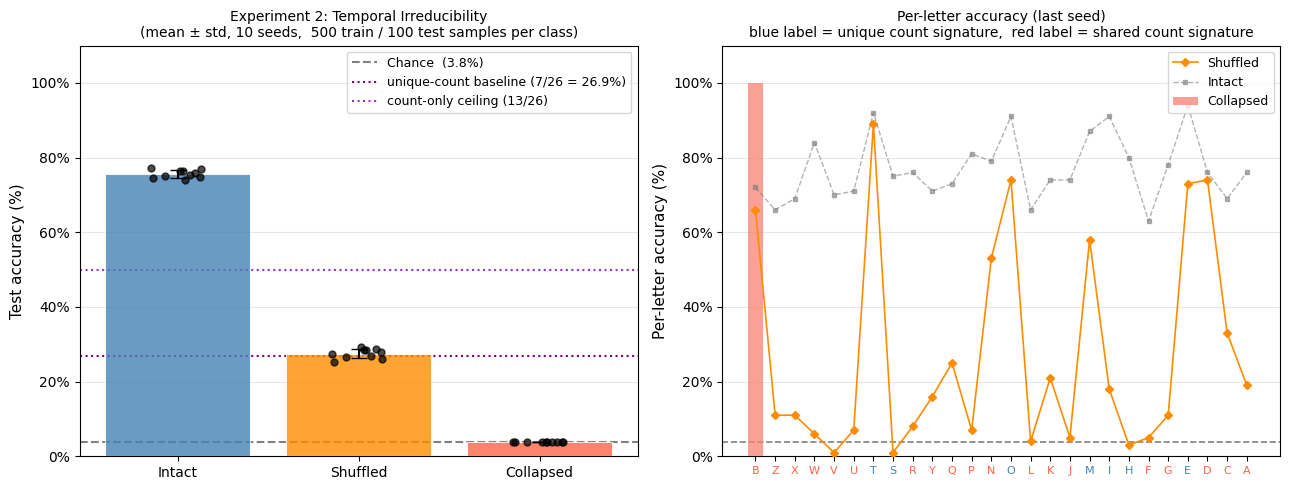

Saved → figures/exp2_temporal_irreducibility.pdf


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: condition comparison ──────────────────────────────────────
ax = axes[0]
conditions  = ['Intact', 'Shuffled', 'Collapsed']
keys        = ['intact', 'shuffled', 'collapsed']
colors      = ['steelblue', 'darkorange', 'tomato']

means_bar = [np.mean([r[k] * 100 for r in all_results]) for k in keys]
stds_bar  = [np.std( [r[k] * 100 for r in all_results]) for k in keys]

bars = ax.bar(conditions, means_bar, color=colors, alpha=0.80, zorder=3,
              edgecolor='white', linewidth=0.8)
ax.errorbar(conditions, means_bar, yerr=stds_bar,
            fmt='none', color='black', capsize=6, lw=1.5, zorder=4)

# Jitter individual seed points
for ci, k in enumerate(keys):
    ys = [r[k] * 100 for r in all_results]
    xs = np.random.default_rng(0).uniform(-0.15, 0.15, len(ys)) + ci
    ax.scatter(xs, ys, color='black', s=25, zorder=5, alpha=0.7)

ax.axhline(100 / N_CLASSES, ls='--', color='gray', lw=1.5,
           label=f'Chance  ({100/N_CLASSES:.1f}%)')
ax.axhline(ceiling, ls=':', color='purple', lw=1.5,
           label=f'unique-count baseline (7/26 = {ceiling:.1f}%)')
ax.axhline(50.0, ls=':', color='darkorchid', lw=1.5,
           label='count-only ceiling (13/26)')

ax.set_ylabel('Test accuracy (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Experiment 2: Temporal Irreducibility\n'
             f'(mean ± std, {N_SEEDS} seeds,  {N_TRAIN} train / {N_TEST} test samples per class)',
             fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.3, zorder=0)

# ── Right panel: per-letter accuracy (last seed) ──────────────────────────
ax = axes[1]
last_per_letter = all_results[-1]['per_letter']
# per_letter_accuracy returns {letter: float}; convert to array in LETTERS order
intact_acc    = np.array([last_per_letter['intact'][l]    for l in LETTERS]) * 100
collapsed_acc = np.array([last_per_letter['collapsed'][l] for l in LETTERS]) * 100
shuffled_acc  = np.array([last_per_letter['shuffled'][l]  for l in LETTERS]) * 100

sort_idx = np.argsort(collapsed_acc)[::-1]
x_pos    = np.arange(N_CLASSES)

# Uniqueness mask (True = unique count signature, False = shared)
unique_mask = np.array([
    len(count_groups[letter_counts[LETTERS[i]]]) == 1
    for i in sort_idx
])

# Use a neutral bar color for collapsed (the bars are nearly all 0%;
# the meaningful color coding is on the tick labels, not the bars)
ax.bar(x_pos, collapsed_acc[sort_idx], color='salmon', alpha=0.75, zorder=3, label='Collapsed')
ax.plot(x_pos, shuffled_acc[sort_idx],  'D-', color='darkorange', ms=4, lw=1.2, zorder=4, label='Shuffled')
ax.plot(x_pos, intact_acc[sort_idx],    's--', color='gray',  ms=3, lw=1.0, zorder=4, label='Intact', alpha=0.6)

ax.set_xticks(x_pos)
ax.set_xticklabels([LETTERS[i] for i in sort_idx], fontsize=8)

# Color tick labels by count-signature uniqueness.
# This is the primary visual encoding: blue = unique signature (identifiable
# from counts alone), red = shared signature (requires temporal ordering).
# Coloring the labels rather than the bars because collapsed bars are ~0%
# for all but one letter, making bar-color coding invisible.
for tick, is_unique in zip(ax.get_xticklabels(), unique_mask):
    tick.set_color('steelblue' if is_unique else 'tomato')

ax.axhline(100 / N_CLASSES, ls='--', color='gray', lw=1.2)
ax.set_ylabel('Per-letter accuracy (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Per-letter accuracy (last seed)\n'
             'blue label = unique count signature,  red label = shared count signature',
             fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.3, zorder=0)

fig.tight_layout()
plt.savefig('../figures/exp2_temporal_irreducibility.pdf', bbox_inches='tight')
plt.show()
print("Saved → figures/exp2_temporal_irreducibility.pdf")

## Summary

In [12]:
print("═" * 62)
print("Experiment 2 — Temporal Irreducibility")
print("═" * 62)
print()
print("Protocol:")
print(f"  WPM      = {WPM}")
print(f"  T_u      = {T_U:.0f} ms")
print(f"  sigma    = {SIGMA} T_u = {SIGMA*T_U:.2f} ms  (fixed)")
print(f"  T_thresh = {T_THRESH} T_u = {T_THRESH*T_U:.2f} ms")
print()
print("Architecture (Multi-Timescale LIF SNN, soft reset):")
n_hid = sum(g[0] for g in TempoSNN.GROUPS)
for n, b, thr in TempoSNN.GROUPS:
    tau = -1.0 / np.log(b)
    print(f"  β={b:.3f}  τ≈{tau:.0f} ms  thr={thr}  n={n}")
print(f"  fc1: 2 → {n_hid}  (Uniform[−2,2] init)")
print(f"  fc2: {n_hid} → 26")
n_params = sum(p.numel() for p in TempoSNN().parameters())
print(f"  Parameters: {n_params:,}  ({n_params/1e3:.1f}k)")
print(f"Training:  {N_EPOCHS} epochs, Adam lr=5e-4→1e-5 (cosine), clip=1.0")
print(f"Dataset:   {N_TRAIN} train / {N_TEST} test samples per class")
print(f"Seeds:     {N_SEEDS}")
print(f"Hardware:  {len(GPU_DEVICES)}× L40S, CUDA graphs, {N_PARALLEL} seeds parallel")
print()
print("Results (mean ± std):")
for col, key in zip(['Intact (%)', 'Shuffled (%)', 'Collapsed (%)'],
                    ['intact', 'shuffled', 'collapsed']):
    vals = [r[key] * 100 for r in all_results]
    print(f"  {col:<18}: {np.mean(vals):.2f} ± {np.std(vals):.2f}")
print()
print(f"Chance level               : {100/N_CLASSES:.2f}%")
print(f"Unique-count baseline       : {ceiling:.1f}%")
print(f"Count-only ceiling          : {count_ceiling:.1f}%")
print()
# Qualitative check
mean_intact    = np.mean([r['intact']    for r in all_results])
mean_collapsed = np.mean([r['collapsed'] for r in all_results])
mean_shuffled  = np.mean([r['shuffled']  for r in all_results])
delta_pp = (mean_intact - mean_shuffled) * 100
print("Qualitative checks (success criteria):")
check1 = "PASS" if mean_intact > 0.70 else "FAIL"
check2 = "PASS" if (mean_intact - mean_shuffled) > 0.30 else "FAIL"
check3 = "PASS" if mean_collapsed < 0.55 else "FAIL"
check4 = "PASS" if np.std([r['intact']*100 for r in all_results]) <= 5.0 else "FAIL"
print(f"  Intact ≥ 70%                     : {check1}  ({mean_intact*100:.1f}%)")
print(f"  Δ(intact − shuffled) ≥ 30 pp     : {check2}  ({delta_pp:+.1f} pp)")
print(f"  Collapsed ≤ 55%                  : {check3}  ({mean_collapsed*100:.1f}%)")
print(f"  Std(intact) ≤ 5%                 : {check4}  ({np.std([r['intact']*100 for r in all_results]):.1f}%)")
print()

# ── Statistical summary ───────────────────────────────────────────────────
n_seeds = len(all_results)
intact_vals    = [r['intact']    * 100 for r in all_results]
shuffled_vals  = [r['shuffled']  * 100 for r in all_results]
collapsed_vals = [r['collapsed'] * 100 for r in all_results]

print('Paired t-tests (one-tailed):')
for label, a, b in [
    ('Intact > Shuffled',    intact_vals,   shuffled_vals),
    ('Shuffled > Collapsed', shuffled_vals, collapsed_vals),
    ('Intact > Collapsed',   intact_vals,   collapsed_vals),
]:
    mu, sd, t, p = paired_t_test(a, b)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {label:<25}: Δ={mu:.2f}pp  t({n_seeds-1})={t:.1f}  p={p:.5f}  {sig}')
print()

print("Figures saved to:")
print("  figures/exp2_temporal_irreducibility.pdf")

══════════════════════════════════════════════════════════════
Experiment 2 — Temporal Irreducibility
══════════════════════════════════════════════════════════════

Protocol:
  WPM      = 20
  T_u      = 60 ms
  sigma    = 0.575 T_u = 34.50 ms  (fixed)
  T_thresh = 1.92 T_u = 115.20 ms

Architecture (Multi-Timescale LIF SNN, soft reset):
  β=0.950  τ≈19 ms  thr=0.3  n=42
  β=0.990  τ≈99 ms  thr=0.4  n=43
  β=0.998  τ≈499 ms  thr=0.5  n=43
  fc1: 2 → 128  (Uniform[−2,2] init)
  fc2: 128 → 26
  Parameters: 3,742  (3.7k)
Training:  100 epochs, Adam lr=5e-4→1e-5 (cosine), clip=1.0
Dataset:   500 train / 100 test samples per class
Seeds:     10
Hardware:  3× L40S, CUDA graphs, 3 seeds parallel

Results (mean ± std):
  Intact (%)        : 75.65 ± 1.04
  Shuffled (%)      : 27.49 ± 1.22
  Collapsed (%)     : 3.85 ± 0.00

Chance level               : 3.85%
Unique-count baseline       : 26.9%
Count-only ceiling          : 50.0%

Qualitative checks (success criteria):
  Intact ≥ 70%            